## Automated Grading and Feedback

#### Abstract

The Automated Essay and Assignment Scoring System enhances the evaluation process by leveraging Natural Language Processing (NLP) and Machine Learning to assess typed submissions with speed, accuracy, and fairness. The system evaluates assignments based on key rubric criteria such as content relevance, grammar, structure, coherence, and originality, ensuring objective and consistent grading.

The framework comprises text preprocessing , feature extraction, and assessment through multiple machine learning and Deep learning models. By automating the grading process, it significantly reduces educators' workload, minimizes subjectivity, and provides students with detailed, data-driven feedback to support academic growth. Additionally, by analyzing large volumes of text, the system enhances assessment transparency and facilitates a more efficient and scalable evaluation process, making grading smarter, faster, and more reliable in the digital age.

## 1 .Dataset Loading

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!pip install gensim==4.3.0

  Using cached scipy-1.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 100.4 MB/s eta 0:00:00
Using cached scipy-1.10.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.9 MB/s eta 0:00:00
  Created wheel for fst-pso: filename=fst_pso-1.8.1-py3-none-any.whl size=20430 sha256=1cf397342992bd0abbc1895df5937ebe904ed1bbbdc262c95e23e04c2017d9db
  Stored in directory: /root/.cache/pip/wheels/69/f5/e5/18ad53fe1ed6b2af9fad05ec052e4acbac8e92441df44bad2e
  Created wheel for miniful: filename=miniful-0.0.6-py3-none-any.whl size=3507 sha256=543bafb7b222a2affd0cb997f89f5c449bba520a8648bb55932206a066

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/EssayScoringDataset/Dataset.csv")
#df=pd.read_csv("/content/Dataset.csv")

df.head()

,score,text
0,0,I think computers are good because you can tal...
1,0,"Being active has no limit, but technology does."
2,0,Computers are good because people can find wha...
3,0,I think that computers are amazing. Computers ...
4,0,"Dear editor, computers are good for people bec..."


#**2. Exploratory Data Analysis (EDA)**




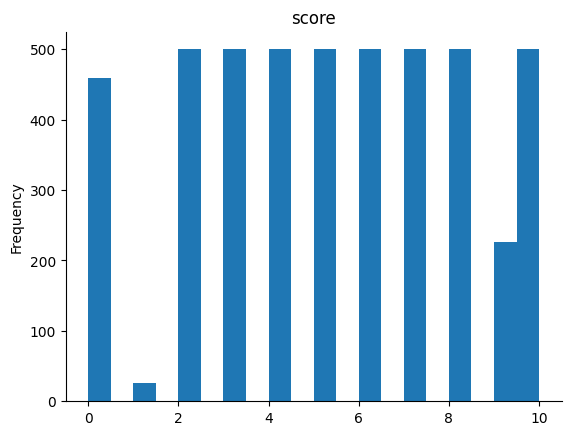

In [ ]:
from matplotlib import pyplot as plt
df['score'].plot(kind='hist', bins=20, title='score')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.shape

(4711, 2)

In [ ]:
df.dropna(axis=1)

,score,text
0,0,I think computers are good because you can tal...
1,0,"Being active has no limit, but technology does."
2,0,Computers are good because people can find wha...
3,0,I think that computers are amazing. Computers ...
4,0,"Dear editor, computers are good for people bec..."
...,...,...
4706,10,The features of the setting affected the cycli...
4707,10,In the essay Rough Road Ahead: Do Not Exceed ...
4708,10,The author concludes this story with the parag...
4709,10,"In the Mooring Mast, by @ORGANIZATION2, the bu..."


In [ ]:
print(df.isna().sum())

score    0
text     0
dtype: int64


In [ ]:
df.rename(columns={"text":'essay'},inplace=True)

##**3. Data Spliting**

In [ ]:
from sklearn.model_selection import train_test_split
training_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
print("Shape of training data:", training_data.shape)
print("Shape of testing data:", test_data.shape)

Shape of training data: (3768, 2)
Shape of testing data: (943, 2)


**#4. Text Preprocessing**





In [ ]:
import re
cList = {
  "ain't": "am not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because",  "could've": "could have","couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not","hadn't've": "had not have","hasn't": "has not",
  "haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he will have","he's": "he is",
  "how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will","I'll've": "I will have","I'm": "I am","I've": "I have",
  "isn't": "is not","it'd": "it had","it'd've": "it would have","it'll": "it will", "it'll've": "it will have","it's": "it is","let's": "let us","ma'am": "madam","mayn't": "may not",
  "might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not","mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not","oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not",
  "shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is",
  "should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so is","that'd": "that would","that'd've": "that would have","that's": "that is","there'd": "there had","there'd've": "there would have","there's": "there is","they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are","they've": "they have","to've": "to have","wasn't": "was not","we'd": "we had",
  "we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have",
  "weren't": "were not","what'll": "what will","what'll've": "what will have",
  "what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have",
  "where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is","who've": "who have","why's": "why is",
  "why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not",
  "wouldn't've": "would not have","y'all": "you all","y'alls": "you alls","y'all'd": "you all would",
  "y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you had","you'd've": "you would have","you'll": "you you will","you'll've": "you you will have","you're": "you are",  "you've": "you have"
   }

c_re = re.compile('(%s)' % '|'.join(cList.keys()))

def expandContractions(text, c_re=c_re):
    def replace(match):
        return cList[match.group(0)]
    return c_re.sub(replace, text)

def removeHTML(x):
    html=re.compile(r'<.*?>')
    return html.sub(r'',x)

def dataPreprocessing(x):
    x = x.lower()
    x = removeHTML(x)
    x = re.sub("@\w+", '',x)
    x = re.sub("'\d+", '',x)
    x = re.sub("\d+", '',x)
    x = re.sub("http\w+", '',x)
    x = re.sub(r"\s+", " ", x)
    x = expandContractions(x)
    x = re.sub(r"\.+", ".", x)
    x = re.sub(r"\,+", ",", x)
    x = re.sub(r'[^a-z\s]', '', x)
    return x

In [ ]:
training_data['essay'] = training_data['essay'].apply(dataPreprocessing)
test_data['essay'] = test_data['essay'].apply(dataPreprocessing)
print(training_data.head())

      score                                              essay
2168      5  the mood created by the author is very welcomi...
1617      4  censorship in libraries differ in certain area...
4315     10  the builders of the empire state building face...
599       2  in my opinion i believe that if the only purpo...
3386      7  there was three main obstacles the builders of...


# **Word Embedding Method 1 : WordToVec**

Word2Vec is a technique in natural language processing (NLP) that represents words as vectors in a high-dimensional space, capturing semantic relationships and context, developed by Google engineers in 2013

In [ ]:
import gensim
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



sentences = [essay.split() for essay in training_data['essay']]
word2vec_model = gensim.models.Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(training_data['essay'])
word_index = tokenizer.word_index

embedding_dim = 100
embedding_matrix = np.zeros((10000, embedding_dim))
for word, i in word_index.items():
    if i < 10000 and word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]


sequences = tokenizer.texts_to_sequences(training_data['essay'])
padded_sequences = pad_sequences(sequences, maxlen=300, padding='post', truncating='post')

print("Embedding Matrix Shape:", embedding_matrix.shape)
print("Embedding Matrix (first 10 rows):")
print(embedding_matrix[:10])

Embedding Matrix Shape: (10000, 100)
Embedding Matrix (first 10 rows):
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.


# **Deep Learning Models**

1.   LSTM
2.   BiLSTM
3.   GRU



## **LSTM**

LSTM (Long Short-Term Memory) is a type of recurrent neural network (RNN) designed to address the vanishing gradient problem and learn long-term dependencies in sequential data, making it effective for tasks like language modeling, speech recognition, and time series prediction

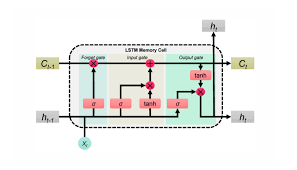

## *Bi-LSTM*

A Bidirectional Long Short-Term Memory (BiLSTM) network is a type of recurrent neural network (RNN) that processes sequential data in both forward and backward directions, enabling it to capture long-term dependencies and context more effectively than traditional LSTMs.
italicized text
In essence, BiLSTMs are a powerful tool for processing sequential data, offering advantages over traditional LSTMs by considering information from both directions of the sequence, leading to improved context understanding and performance in various applications


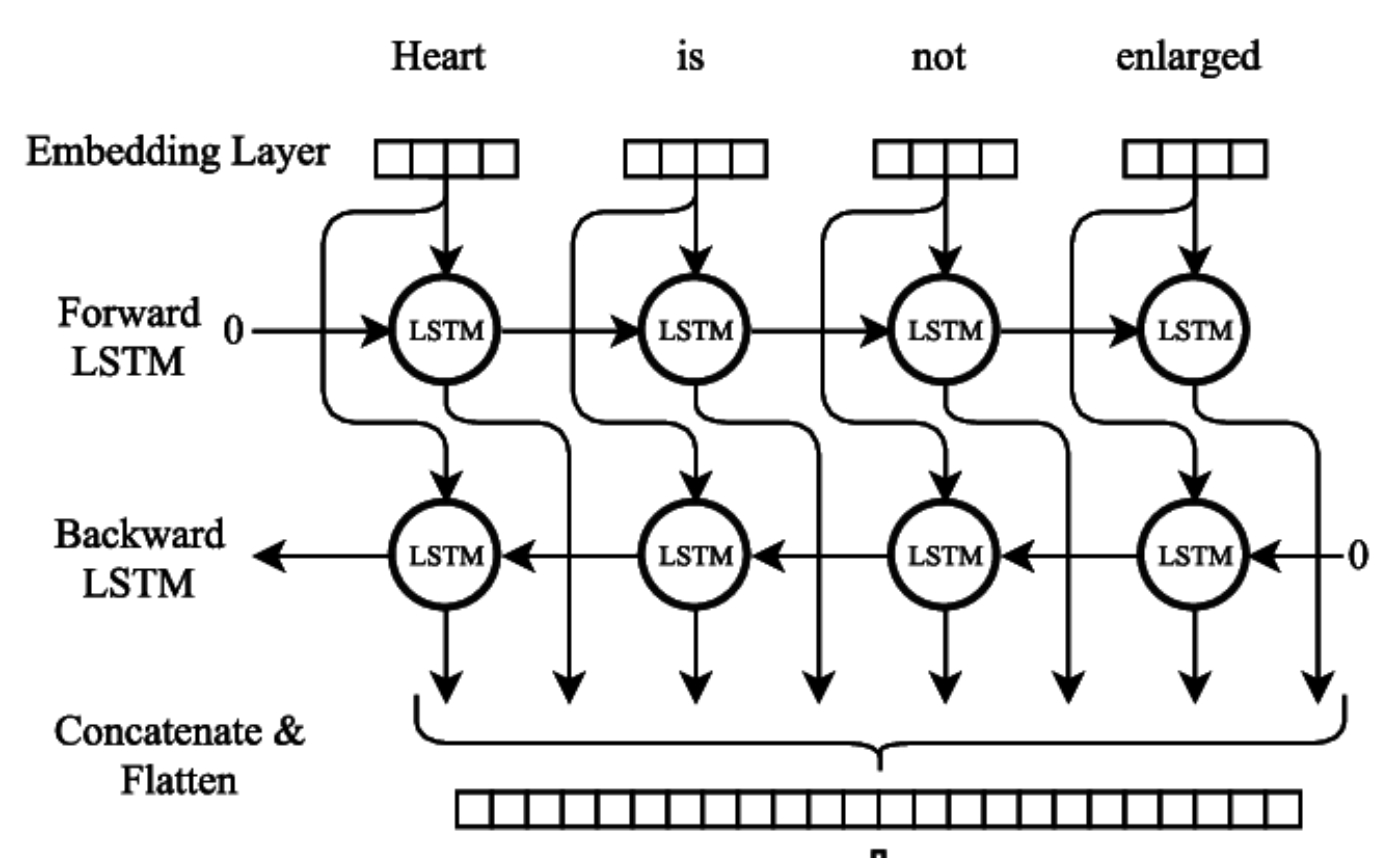

**GRU**

A Gated Recurrent Unit (GRU) is a type of recurrent neural network (RNN) architecture, similar to Long Short-Term Memory (LSTM), but with a simpler structure, designed to capture dependencies in sequential data using update and reset gates

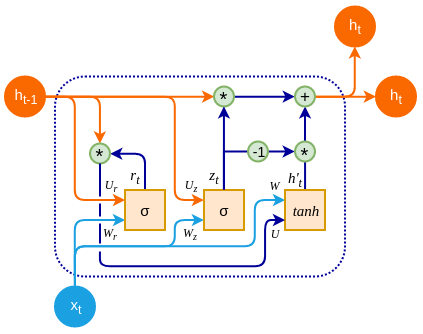

**Models**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Bidirectional, GlobalMaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

def r2_score(y_true, y_pred):
    y_true = K.cast(y_true, dtype='float32')
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - (SS_res / (SS_tot + K.epsilon()))
def bilstm_model():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=embedding_dim, input_length=300,
                  weights=[embedding_matrix], trainable=False),
        Bidirectional(LSTM(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="linear")
    ])

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss="mean_squared_error", metrics=['mae', 'mse', r2_score])
    return model


def lstm_model():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=embedding_dim, input_length=300,
                  weights=[embedding_matrix], trainable=False),
        LSTM(64, return_sequences=True),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="linear")
    ])

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss="mean_squared_error", metrics=['mae', 'mse', r2_score])
    return model


def gru_model():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=embedding_dim, input_length=300,
                  weights=[embedding_matrix], trainable=False),
        GRU(64, return_sequences=True),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="linear")
    ])

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss="mean_squared_error", metrics=['mae', 'mse', r2_score])
    return model


# **5.Model Training**



**Model : LSTM + WordToVec**




In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
qwk_scores = []

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for fold, (train_idx, val_idx) in enumerate(kfold.split(padded_sequences)):
    print(f"Training fold {fold + 1}")

    X_train, X_val = padded_sequences[train_idx], padded_sequences[val_idx]
    y_train, y_val = training_data['score'].iloc[train_idx], training_data['score'].iloc[val_idx]

    model = lstm_model()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=1,
        callbacks=[early_stopping]
    )

    score = model.evaluate(X_val, y_val, verbose=0)
    fold_scores.append(score)

    y_val_pred = model.predict(X_val).flatten()
    y_val_pred = np.round(y_val_pred)
    qwk_score = cohen_kappa_score(y_val, y_val_pred, weights='quadratic')
    qwk_scores.append(qwk_score)

    print(f"Fold {fold+1} QWK score: {qwk_score}")

print(f"Validation scores from each fold: {fold_scores}")
print(f"Mean cross-validation score: {np.mean(fold_scores)}")
print(f"Mean QWK score: {np.mean(qwk_scores)}")


Training fold 1
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 32.3408 - mae: 4.8837 - mse: 32.3408 - r2_score: -2.8294 - val_loss: 10.9098 - val_mae: 2.6645 - val_mse: 10.9098 - val_r2_score: -0.2713
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.7611 - mae: 2.5560 - mse: 9.7611 - r2_score: -0.1958 - val_loss: 7.2333 - val_mae: 2.2712 - val_mse: 7.2333 - val_r2_score: 0.1628
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.4280 - mae: 2.2542 - mse: 7.4280 - r2_score: 0.0824 - val_loss: 6.3126 - val_mae: 2.1095 - val_mse: 6.3126 - val_r2_score: 0.2703
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.4791 - mae: 2.0921 - mse: 6.4791 - r2_score: 0.2182 - val_loss: 5.5137 - val_mae: 1.9445 - val_mse: 5.5137 - val_r2_score: 0.3625
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5.9419 - mae: 1.9450 - mse: 5.9419 - r2_score: 0.3053 - val_loss: 4.8088 - val_mae: 1.7834 - val_mse: 4.8088 - val_r2_score: 0.4441
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15m

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 24.1132 - mae: 4.1172 - mse: 24.1132 - r2_score: -1.8124 - val_loss: 8.0731 - val_mae: 2.3409 - val_mse: 8.0731 - val_r2_score: -0.0299
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.5845 - mae: 2.4548 - mse: 8.5845 - r2_score: -0.0195 - val_loss: 6.6522 - val_mae: 2.1473 - val_mse: 6.6522 - val_r2_score: 0.1570
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 7.5613 - mae: 2.3004 - mse: 7.5613 - r2_score: 0.1416 - val_loss: 5.6399 - val_mae: 1.9518 - val_mse: 5.6399 - val_r2_score: 0.2868
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 6.1590 - mae: 2.0368 - mse: 6.1590 - r2_score: 0.2817 - val_loss: 4.6650 - val_mae: 1.6992 - val_mse: 4.6650 - val_r2_score: 0.4105
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 4.9466 - mae: 1.7607 - mse: 4.9466 - r2_score: 0.4173 - val_loss: 4.1553 - val_mae: 1.6044 - val_mse: 4.1553 - val_r2_score: 0.4692
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 26.8882 - mae: 4.3862 - mse: 26.8882 - r2_score: -2.2322 - val_loss: 10.4080 - val_mae: 2.6509 - val_mse: 10.4080 - val_r2_score: -0.2103
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 9.3466 - mae: 2.5282 - mse: 9.3466 - r2_score: -0.0860 - val_loss: 7.6921 - val_mae: 2.3830 - val_mse: 7.6921 - val_r2_score: 0.1142
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 7.6127 - mae: 2.2991 - mse: 7.6127 - r2_score: 0.0878 - val_loss: 6.8363 - val_mae: 2.2340 - val_mse: 6.8363 - val_r2_score: 0.2142
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 6.6129 - mae: 2.1299 - mse: 6.6129 - r2_score: 0.2092 - val_loss: 5.8120 - val_mae: 2.0057 - val_mse: 5.8120 - val_r2_score: 0.3337
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.6689 - mae: 1.9343 - mse: 5.6689 - r2_score: 0.3094 - val_loss: 4.9281 - val_mae: 1.7910 - val_mse: 4.9281 - val_r2_score: 0.4350
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23m

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 21.8581 - mae: 3.9046 - mse: 21.8581 - r2_score: -1.6794 - val_loss: 8.6782 - val_mae: 2.4550 - val_mse: 8.6782 - val_r2_score: -0.0052
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.7646 - mae: 2.3243 - mse: 7.7646 - r2_score: 0.0492 - val_loss: 7.3448 - val_mae: 2.2699 - val_mse: 7.3448 - val_r2_score: 0.1456
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 7.1213 - mae: 2.2121 - mse: 7.1213 - r2_score: 0.1225 - val_loss: 6.6308 - val_mae: 2.1302 - val_mse: 6.6308 - val_r2_score: 0.2290
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 6.3764 - mae: 2.0651 - mse: 6.3764 - r2_score: 0.2229 - val_loss: 5.6728 - val_mae: 1.9261 - val_mse: 5.6728 - val_r2_score: 0.3380
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.2856 - mae: 1.8387 - mse: 5.2856 - r2_score: 0.3570 - val_loss: 5.0190 - val_mae: 1.7546 - val_mse: 5.0190 - val_r2_score: 0.4130
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 30.5662 - mae: 4.7230 - mse: 30.5662 - r2_score: -2.6588 - val_loss: 14.3316 - val_mae: 3.1319 - val_mse: 14.3316 - val_r2_score: -0.6957
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 10.8537 - mae: 2.6874 - mse: 10.8537 - r2_score: -0.2968 - val_loss: 7.9113 - val_mae: 2.3569 - val_mse: 7.9113 - val_r2_score: 0.0675
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 7.8700 - mae: 2.3573 - mse: 7.8700 - r2_score: 0.0806 - val_loss: 7.1631 - val_mae: 2.2239 - val_mse: 7.1631 - val_r2_score: 0.1569
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 7.0123 - mae: 2.1908 - mse: 7.0123 - r2_score: 0.1740 - val_loss: 6.1648 - val_mae: 2.0133 - val_mse: 6.1648 - val_r2_score: 0.2779
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.8689 - mae: 1.9635 - mse: 5.8689 - r2_score: 0.3120 - val_loss: 5.1233 - val_mae: 1.7950 - val_mse: 5.1233 - val_r2_score: 0.3978
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 1

 **Model Result (WordtoVec + LSTM)**


*   QWK score: 0.7882874459373582
*   Cross-validation score: 1.9957926779985429



**Model (BilSTM + WordtoVec)**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
qwk_scores = []

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for fold, (train_idx, val_idx) in enumerate(kfold.split(padded_sequences)):
    print(f"Training fold {fold + 1}")
    X_train, X_val = padded_sequences[train_idx], padded_sequences[val_idx]
    y_train, y_val = training_data['score'].iloc[train_idx], training_data['score'].iloc[val_idx]
    model = bilstm_model()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=1,
        callbacks=[early_stopping]
    )
    score = model.evaluate(X_val, y_val, verbose=0)
    fold_scores.append(score)
    y_val_pred = model.predict(X_val).flatten()
    y_val_pred = np.round(y_val_pred)
    qwk_score = cohen_kappa_score(y_val, y_val_pred, weights='quadratic')
    qwk_scores.append(qwk_score)
    print(f"Fold {fold+1} QWK score: {qwk_score}")
print(f"Validation scores from each fold: {fold_scores}")
print(f"Mean cross-validation score: {np.mean(fold_scores)}")
print(f"Mean QWK score: {np.mean(qwk_scores)}")

Training fold 1
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 20.7622 - mae: 3.7656 - mse: 20.7622 - r2_score: -1.4652 - val_loss: 7.4383 - val_mae: 2.3029 - val_mse: 7.4383 - val_r2_score: 0.1369
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 7.6573 - mae: 2.2996 - mse: 7.6573 - r2_score: 0.0756 - val_loss: 6.6092 - val_mae: 2.1650 - val_mse: 6.6092 - val_r2_score: 0.2340
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 7.2334 - mae: 2.2217 - mse: 7.2334 - r2_score: 0.1748 - val_loss: 5.6079 - val_mae: 1.9664 - val_mse: 5.6079 - val_r2_score: 0.3493
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 5.7984 - mae: 1.9562 - mse: 5.7984 - r2_score: 0.3005 - val_loss: 4.7441 - val_mae: 1.7709 - val_mse: 4.7441 - val_r2_score: 0.4491
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 5.2296 - mae: 1.8244 - mse: 5.2296 - r2_score: 0.3805 - val_loss: 4.1760 - val_mae: 1.6480 - val_mse: 4.1760 - val_r2_score: 0.5124
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/st

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 26.7971 - mae: 4.3456 - mse: 26.7971 - r2_score: -2.1378 - val_loss: 7.0817 - val_mae: 2.2129 - val_mse: 7.0817 - val_r2_score: 0.1012
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.9944 - mae: 2.3676 - mse: 7.9944 - r2_score: 0.0665 - val_loss: 6.3475 - val_mae: 2.1016 - val_mse: 6.3475 - val_r2_score: 0.1973
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.3114 - mae: 2.2667 - mse: 7.3114 - r2_score: 0.1699 - val_loss: 5.5054 - val_mae: 1.9312 - val_mse: 5.5054 - val_r2_score: 0.3037
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 6.2702 - mae: 2.0774 - mse: 6.2702 - r2_score: 0.2827 - val_loss: 4.7111 - val_mae: 1.7393 - val_mse: 4.7111 - val_r2_score: 0.4029
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 5.2387 - mae: 1.8425 - mse: 5.2387 - r2_score: 0.4070 - val_loss: 4.1459 - val_mae: 1.6107 - val_mse: 4.1459 - val_r2_score: 0.4742
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/st

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 24.8825 - mae: 4.1669 - mse: 24.8825 - r2_score: -2.0591 - val_loss: 7.7528 - val_mae: 2.3723 - val_mse: 7.7528 - val_r2_score: 0.1057
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.8579 - mae: 2.3244 - mse: 7.8579 - r2_score: 0.0726 - val_loss: 6.6116 - val_mae: 2.1813 - val_mse: 6.6116 - val_r2_score: 0.2395
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 6.3591 - mae: 2.0724 - mse: 6.3591 - r2_score: 0.2235 - val_loss: 5.5908 - val_mae: 1.9518 - val_mse: 5.5908 - val_r2_score: 0.3588
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 5.5284 - mae: 1.9116 - mse: 5.5284 - r2_score: 0.3388 - val_loss: 4.7315 - val_mae: 1.7505 - val_mse: 4.7315 - val_r2_score: 0.4581
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 5.1349 - mae: 1.8078 - mse: 5.1349 - r2_score: 0.4017 - val_loss: 4.3042 - val_mae: 1.6509 - val_mse: 4.3042 - val_r2_score: 0.5069
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/st

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 21.2502 - mae: 3.8084 - mse: 21.2502 - r2_score: -1.5527 - val_loss: 7.4180 - val_mae: 2.2771 - val_mse: 7.4180 - val_r2_score: 0.1381
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 7.2650 - mae: 2.2631 - mse: 7.2650 - r2_score: 0.1573 - val_loss: 6.3801 - val_mae: 2.0808 - val_mse: 6.3801 - val_r2_score: 0.2586
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 6.0012 - mae: 2.0155 - mse: 6.0012 - r2_score: 0.2659 - val_loss: 5.5164 - val_mae: 1.8873 - val_mse: 5.5164 - val_r2_score: 0.3593
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 5.3212 - mae: 1.8663 - mse: 5.3212 - r2_score: 0.3618 - val_loss: 4.8747 - val_mae: 1.7433 - val_mse: 4.8747 - val_r2_score: 0.4320
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 4.6060 - mae: 1.6894 - mse: 4.6060 - r2_score: 0.4249 - val_loss: 4.7005 - val_mae: 1.6852 - val_mse: 4.7005 - val_r2_score: 0.4544
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 22.8949 - mae: 3.9789 - mse: 22.8949 - r2_score: -1.8569 - val_loss: 7.4384 - val_mae: 2.2831 - val_mse: 7.4384 - val_r2_score: 0.1232
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 7.4768 - mae: 2.2893 - mse: 7.4768 - r2_score: 0.0971 - val_loss: 6.6350 - val_mae: 2.1229 - val_mse: 6.6350 - val_r2_score: 0.2195
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 6.4308 - mae: 2.1021 - mse: 6.4308 - r2_score: 0.2223 - val_loss: 5.8533 - val_mae: 1.9423 - val_mse: 5.8533 - val_r2_score: 0.3144
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 5.7301 - mae: 1.9466 - mse: 5.7301 - r2_score: 0.3272 - val_loss: 5.0732 - val_mae: 1.7621 - val_mse: 5.0732 - val_r2_score: 0.4065
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 4.8416 - mae: 1.7584 - mse: 4.8416 - r2_score: 0.4210 - val_loss: 4.3847 - val_mae: 1.6323 - val_mse: 4.3847 - val_r2_score: 0.4850
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/st

**Model Result ( WordtoVec + BiLSTM):**

Cross-validation score: 1.54

Qwk Score : 0.80



In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
qwk_scores = []

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for fold, (train_idx, val_idx) in enumerate(kfold.split(padded_sequences)):
    print(f"Training fold {fold + 1}")
    X_train, X_val = padded_sequences[train_idx], padded_sequences[val_idx]
    y_train, y_val = training_data['score'].iloc[train_idx], training_data['score'].iloc[val_idx]
    model = gru_model()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=1,
        callbacks=[early_stopping]
    )
    score = model.evaluate(X_val, y_val, verbose=0)
    fold_scores.append(score)
    y_val_pred = model.predict(X_val).flatten()
    y_val_pred = np.round(y_val_pred)
    qwk_score = cohen_kappa_score(y_val, y_val_pred, weights='quadratic')
    qwk_scores.append(qwk_score)
    print(f"Fold {fold+1} QWK score: {qwk_score}")
print(f"Validation scores from each fold: {fold_scores}")
print(f"Mean cross-validation score: {np.mean(fold_scores)}")
print(f"Mean QWK score: {np.mean(qwk_scores)}")

Training fold 1
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 25.8730 - mae: 4.2888 - mse: 25.8730 - r2_score: -2.0161 - val_loss: 9.2601 - val_mae: 2.4952 - val_mse: 9.2601 - val_r2_score: -0.0731
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.0674 - mae: 2.5030 - mse: 9.0674 - r2_score: -0.0730 - val_loss: 7.6416 - val_mae: 2.3450 - val_mse: 7.6416 - val_r2_score: 0.1151
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 7.7055 - mae: 2.3370 - mse: 7.7055 - r2_score: 0.0686 - val_loss: 7.0476 - val_mae: 2.2509 - val_mse: 7.0476 - val_r2_score: 0.1839
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.7690 - mae: 2.1601 - mse: 6.7690 - r2_score: 0.1699 - val_loss: 6.3845 - val_mae: 2.1308 - val_mse: 6.3845 - val_r2_score: 0.2609
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 6.7466 - mae: 2.1567 - mse: 6.7466 - r2_score: 0.2111 - val_loss: 5.8726 - val_mae: 2.0325 - val_mse: 5.8726 - val_r2_score: 0.3195
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 22.6968 - mae: 3.9810 - mse: 22.6968 - r2_score: -1.6709 - val_loss: 8.0629 - val_mae: 2.3472 - val_mse: 8.0629 - val_r2_score: -0.0287
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 9.3677 - mae: 2.5788 - mse: 9.3677 - r2_score: -0.0799 - val_loss: 6.8885 - val_mae: 2.1900 - val_mse: 6.8885 - val_r2_score: 0.1264
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 8.0393 - mae: 2.3981 - mse: 8.0393 - r2_score: 0.0762 - val_loss: 6.3015 - val_mae: 2.0889 - val_mse: 6.3015 - val_r2_score: 0.2013
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 7.1625 - mae: 2.2285 - mse: 7.1625 - r2_score: 0.1811 - val_loss: 5.6753 - val_mae: 1.9594 - val_mse: 5.6753 - val_r2_score: 0.2804
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 6.4897 - mae: 2.0920 - mse: 6.4897 - r2_score: 0.2380 - val_loss: 5.1808 - val_mae: 1.8506 - val_mse: 5.1808 - val_r2_score: 0.3428
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 27.4022 - mae: 4.4488 - mse: 27.4022 - r2_score: -2.4274 - val_loss: 10.8776 - val_mae: 2.7040 - val_mse: 10.8776 - val_r2_score: -0.2669
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 9.4236 - mae: 2.5232 - mse: 9.4236 - r2_score: -0.1322 - val_loss: 7.9235 - val_mae: 2.4202 - val_mse: 7.9235 - val_r2_score: 0.0863
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 8.2828 - mae: 2.4054 - mse: 8.2828 - r2_score: 0.0334 - val_loss: 7.2502 - val_mae: 2.3098 - val_mse: 7.2502 - val_r2_score: 0.1648
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.3525 - mae: 2.2385 - mse: 7.3525 - r2_score: 0.1117 - val_loss: 6.5459 - val_mae: 2.1781 - val_mse: 6.5459 - val_r2_score: 0.2470
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 6.8721 - mae: 2.1628 - mse: 6.8721 - r2_score: 0.1971 - val_loss: 5.8996 - val_mae: 2.0447 - val_mse: 5.8996 - val_r2_score: 0.3223
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15m

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 22.4458 - mae: 3.9494 - mse: 22.4458 - r2_score: -1.7023 - val_loss: 8.9509 - val_mae: 2.5057 - val_mse: 8.9509 - val_r2_score: -0.0373
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 8.3020 - mae: 2.4142 - mse: 8.3020 - r2_score: 0.0241 - val_loss: 7.7893 - val_mae: 2.3390 - val_mse: 7.7893 - val_r2_score: 0.0933
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 7.5934 - mae: 2.2979 - mse: 7.5934 - r2_score: 0.0908 - val_loss: 7.1993 - val_mae: 2.2333 - val_mse: 7.1993 - val_r2_score: 0.1618
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 6.9275 - mae: 2.1903 - mse: 6.9275 - r2_score: 0.1750 - val_loss: 6.5300 - val_mae: 2.1053 - val_mse: 6.5300 - val_r2_score: 0.2395
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.1481 - mae: 2.0483 - mse: 6.1481 - r2_score: 0.2575 - val_loss: 6.0223 - val_mae: 1.9947 - val_mse: 6.0223 - val_r2_score: 0.3002
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 27.0794 - mae: 4.3908 - mse: 27.0794 - r2_score: -2.3281 - val_loss: 11.0912 - val_mae: 2.7614 - val_mse: 11.0912 - val_r2_score: -0.3073
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 9.8358 - mae: 2.5964 - mse: 9.8358 - r2_score: -0.1190 - val_loss: 7.8626 - val_mae: 2.3505 - val_mse: 7.8626 - val_r2_score: 0.0746
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.8641 - mae: 2.3370 - mse: 7.8641 - r2_score: 0.0711 - val_loss: 7.2189 - val_mae: 2.2450 - val_mse: 7.2189 - val_r2_score: 0.1501
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 7.4964 - mae: 2.2805 - mse: 7.4964 - r2_score: 0.1367 - val_loss: 6.6518 - val_mae: 2.1304 - val_mse: 6.6518 - val_r2_score: 0.2172
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 6.6749 - mae: 2.1340 - mse: 6.6749 - r2_score: 0.2118 - val_loss: 6.1803 - val_mae: 2.0370 - val_mse: 6.1803 - val_r2_score: 0.2734
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 17m

**Model Result ( WordtoVec + GRU):**

Cross-validation score: 2.195

Qwk Score : 0.755



## Section 4: TFIDF

 Term Frequency-Inverse Document Frequency, is a numerical statistic used in information retrieval and machine learning to evaluate the importance of a word in a document within a collection or corpus. It's calculated by multiplying term frequency (TF) with inverse document frequency (IDF).

 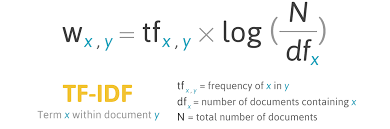

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(training_data['essay'])
word_index = tokenizer.word_index
vectorizer = TfidfVectorizer(max_features=10000)
tfidf_matrix = vectorizer.fit_transform(training_data['essay']).toarray()
feature_names = vectorizer.get_feature_names_out()
embedding_dim = 100
embedding_matrix = np.zeros((10000, embedding_dim))
for i, word in enumerate(feature_names):
    if word in word_index and word_index[word] < 10000:
        embedding_matrix[word_index[word]] = tfidf_matrix[:, i].mean()

sequences = tokenizer.texts_to_sequences(training_data['essay'])
padded_sequences = pad_sequences(sequences, maxlen=300, padding='post', truncating='post')

**Model : BiLSTM + TFIDF**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
qwk_scores = []

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for fold, (train_idx, val_idx) in enumerate(kfold.split(padded_sequences)):
    print(f"Training fold {fold + 1}")
    X_train, X_val = padded_sequences[train_idx], padded_sequences[val_idx]
    y_train, y_val = training_data['score'].iloc[train_idx], training_data['score'].iloc[val_idx]
    model2 = bilstm_model()
    history = model2.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=1,
        callbacks=[early_stopping]
    )
    score = model2.evaluate(X_val, y_val, verbose=0)
    fold_scores.append(score)
    y_val_pred = model2.predict(X_val).flatten()
    y_val_pred = np.round(y_val_pred)
    qwk_score = cohen_kappa_score(y_val, y_val_pred, weights='quadratic')
    qwk_scores.append(qwk_score)

    print(f"Fold {fold+1} QWK score: {qwk_score}")


print(f"Validation scores from each fold: {fold_scores}")
print(f"Mean cross-validation score: {np.mean(fold_scores)}")
print(f"Mean QWK score: {np.mean(qwk_scores)}")


Training fold 1
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.0683 - loss: 30.9569 - mae: 4.7928 - mse: 30.9569 - r2_score: -2.7536 - val_accuracy: 0.0040 - val_loss: 8.4415 - val_mae: 2.4301 - val_mse: 8.4415 - val_r2_score: 0.0228
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0042 - loss: 8.6023 - mae: 2.4560 - mse: 8.6023 - r2_score: -0.0416 - val_accuracy: 0.0040 - val_loss: 7.7139 - val_mae: 2.3452 - val_mse: 7.7139 - val_r2_score: 0.1037
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.0037 - loss: 8.0420 - mae: 2.3815 - mse: 8.0420 - r2_score: 0.0587 - val_accuracy: 0.0066 - val_loss: 6.0214 - val_mae: 2.0364 - val_mse: 6.0214 - val_r2_score: 0.2892
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.0054 - loss: 6.5468 - mae: 2.0886 - mse: 6.5468 - r2_score: 0.2429 - val_accuracy: 0.0066 - val_loss: 4.9673 - val_mae: 1.8421 - val_mse: 4.9673 - val_r2_score: 0.4135
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0053 -

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.0740 - loss: 35.5478 - mae: 5.1943 - mse: 35.5478 - r2_score: -3.3074 - val_accuracy: 0.0027 - val_loss: 13.1410 - val_mae: 2.9376 - val_mse: 13.1410 - val_r2_score: -0.6912
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0056 - loss: 10.9890 - mae: 2.7483 - mse: 10.9890 - r2_score: -0.2800 - val_accuracy: 0.0027 - val_loss: 7.8069 - val_mae: 2.3284 - val_mse: 7.8069 - val_r2_score: 0.0096
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0062 - loss: 8.7306 - mae: 2.4994 - mse: 8.7306 - r2_score: -0.0205 - val_accuracy: 0.0027 - val_loss: 7.1352 - val_mae: 2.2158 - val_mse: 7.1352 - val_r2_score: 0.0946
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.0068 - loss: 7.6424 - mae: 2.3107 - mse: 7.6424 - r2_score: 0.1133 - val_accuracy: 0.0027 - val_loss: 5.4716 - val_mae: 1.9222 - val_mse: 5.4716 - val_r2_score: 0.3068
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.0718 - loss: 32.1998 - mae: 4.9039 - mse: 32.1998 - r2_score: -2.9414 - val_accuracy: 0.0093 - val_loss: 8.7113 - val_mae: 2.5176 - val_mse: 8.7113 - val_r2_score: -0.0060
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.0053 - loss: 8.4985 - mae: 2.4363 - mse: 8.4985 - r2_score: -0.0077 - val_accuracy: 0.0093 - val_loss: 8.0537 - val_mae: 2.4107 - val_mse: 8.0537 - val_r2_score: 0.0718
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.0029 - loss: 7.5561 - mae: 2.2740 - mse: 7.5561 - r2_score: 0.0973 - val_accuracy: 0.0106 - val_loss: 6.2784 - val_mae: 2.0844 - val_mse: 6.2784 - val_r2_score: 0.2724
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.0049 - loss: 6.4960 - mae: 2.0898 - mse: 6.4960 - r2_score: 0.2158 - val_accuracy: 0.0093 - val_loss: 5.2640 - val_mae: 1.8921 - val_mse: 5.2640 - val_r2_score: 0.3871
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.0053 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.0923 - loss: 33.0297 - mae: 4.9430 - mse: 33.0297 - r2_score: -2.9020 - val_accuracy: 0.0040 - val_loss: 10.8261 - val_mae: 2.7183 - val_mse: 10.8261 - val_r2_score: -0.2534
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.0039 - loss: 9.3656 - mae: 2.5452 - mse: 9.3656 - r2_score: -0.1354 - val_accuracy: 0.0040 - val_loss: 8.5878 - val_mae: 2.4569 - val_mse: 8.5878 - val_r2_score: 0.0059
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0067 - loss: 8.2891 - mae: 2.4039 - mse: 8.2891 - r2_score: 0.0510 - val_accuracy: 0.0040 - val_loss: 9.0222 - val_mae: 2.4752 - val_mse: 9.0222 - val_r2_score: -0.0398
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.0090 - loss: 7.4969 - mae: 2.2722 - mse: 7.4969 - r2_score: 0.1236 - val_accuracy: 0.0040 - val_loss: 5.8342 - val_mae: 2.0126 - val_mse: 5.8342 - val_r2_score: 0.3207
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.00

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.0769 - loss: 33.7441 - mae: 5.0403 - mse: 33.7441 - r2_score: -3.1931 - val_accuracy: 0.0053 - val_loss: 12.3353 - val_mae: 2.9321 - val_mse: 12.3353 - val_r2_score: -0.4554
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.0078 - loss: 10.1475 - mae: 2.6489 - mse: 10.1475 - r2_score: -0.1977 - val_accuracy: 0.0053 - val_loss: 8.4522 - val_mae: 2.4451 - val_mse: 8.4522 - val_r2_score: 0.0053
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0047 - loss: 8.7671 - mae: 2.4840 - mse: 8.7671 - r2_score: -0.0237 - val_accuracy: 0.0053 - val_loss: 7.6254 - val_mae: 2.3166 - val_mse: 7.6254 - val_r2_score: 0.1019
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0044 - loss: 7.8051 - mae: 2.3136 - mse: 7.8051 - r2_score: 0.0940 - val_accuracy: 0.0053 - val_loss: 7.6726 - val_mae: 2.2951 - val_mse: 7.6726 - val_r2_score: 0.0952
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0

**Model Result: (BiLSTM + TF-IDF)**

Cross-validation score: 2.346

Qwk Score : 0.625

**Model : LSTM + TFIDF**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
qwk_scores = []
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
for fold, (train_idx, val_idx) in enumerate(kfold.split(padded_sequences)):
    print(f"Training fold {fold + 1}")
    X_train, X_val = padded_sequences[train_idx], padded_sequences[val_idx]
    y_train, y_val = training_data['score'].iloc[train_idx], training_data['score'].iloc[val_idx]
    model2 = lstm_model()
    history = model2.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=1,
        callbacks=[early_stopping]
    )
    score = model2.evaluate(X_val, y_val, verbose=0)
    fold_scores.append(score)
    y_val_pred = model2.predict(X_val).flatten()
    y_val_pred = np.round(y_val_pred)  # Round predictions for QWK calculation
    qwk_score = cohen_kappa_score(y_val, y_val_pred, weights='quadratic')
    qwk_scores.append(qwk_score)
    print(f"Fold {fold+1} QWK score: {qwk_score}")
print(f"Validation scores from each fold: {fold_scores}")
print(f"Mean cross-validation score: {np.mean(fold_scores)}")
print(f"Mean QWK score: {np.mean(qwk_scores)}")


Training fold 1
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 34.9400 - mae: 5.1540 - mse: 34.9400 - r2_score: -3.4098 - val_loss: 20.3692 - val_mae: 3.7632 - val_mse: 20.3692 - val_r2_score: -1.4105
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 13.7901 - mae: 3.0507 - mse: 13.7901 - r2_score: -0.6876 - val_loss: 8.6725 - val_mae: 2.4918 - val_mse: 8.6725 - val_r2_score: -0.0040
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 9.0297 - mae: 2.5283 - mse: 9.0297 - r2_score: -0.0518 - val_loss: 8.2270 - val_mae: 2.4327 - val_mse: 8.2270 - val_r2_score: 0.0460
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.1652 - mae: 2.3926 - mse: 8.1652 - r2_score: 0.0239 - val_loss: 5.7048 - val_mae: 1.9757 - val_mse: 5.7048 - val_r2_score: 0.3299
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.4394 - mae: 2.0871 - mse: 6.4394 - r2_score: 0.2315 - val_loss: 4.9893 - val_mae: 1.8416 - val_mse: 4.9893 - val_r2_score: 0.4095
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 35.3190 - mae: 5.1585 - mse: 35.3190 - r2_score: -3.1951 - val_loss: 16.4359 - val_mae: 3.3374 - val_mse: 16.4359 - val_r2_score: -1.1207
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 12.5774 - mae: 2.9350 - mse: 12.5774 - r2_score: -0.4786 - val_loss: 7.8007 - val_mae: 2.3323 - val_mse: 7.8007 - val_r2_score: 0.0110
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.8235 - mae: 2.5006 - mse: 8.8235 - r2_score: -0.0229 - val_loss: 7.2879 - val_mae: 2.2450 - val_mse: 7.2879 - val_r2_score: 0.0766
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.7668 - mae: 2.3117 - mse: 7.7668 - r2_score: 0.0902 - val_loss: 5.5759 - val_mae: 1.9242 - val_mse: 5.5759 - val_r2_score: 0.2958
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.8575 - mae: 1.9812 - mse: 5.8575 - r2_score: 0.3289 - val_loss: 6.1169 - val_mae: 2.0295 - val_mse: 6.1169 - val_r2_score: 0.2282
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 35.4305 - mae: 5.1693 - mse: 35.4305 - r2_score: -3.2385 - val_loss: 26.6200 - val_mae: 4.4006 - val_mse: 26.6200 - val_r2_score: -2.1472
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 19.7525 - mae: 3.7035 - mse: 19.7525 - r2_score: -1.4000 - val_loss: 11.4644 - val_mae: 2.8349 - val_mse: 11.4644 - val_r2_score: -0.3361
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 10.3064 - mae: 2.6695 - mse: 10.3064 - r2_score: -0.2235 - val_loss: 9.2708 - val_mae: 2.6124 - val_mse: 9.2708 - val_r2_score: -0.0725
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 9.0686 - mae: 2.5244 - mse: 9.0686 - r2_score: -0.0709 - val_loss: 8.9859 - val_mae: 2.5807 - val_mse: 8.9859 - val_r2_score: -0.0381
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 9.0021 - mae: 2.5083 - mse: 9.0021 - r2_score: -0.0906 - val_loss: 8.7729 - val_mae: 2.5441 - val_mse: 8.7729 - val_r2_score: -0.0134
Epoch 6/100
95/95 ━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 34.3392 - mae: 5.1189 - mse: 34.3392 - r2_score: -3.4122 - val_loss: 20.1760 - val_mae: 3.7191 - val_mse: 20.1760 - val_r2_score: -1.3582
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 14.0942 - mae: 3.0831 - mse: 14.0942 - r2_score: -0.6286 - val_loss: 9.0671 - val_mae: 2.5308 - val_mse: 9.0671 - val_r2_score: -0.0517
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 8.8104 - mae: 2.4928 - mse: 8.8104 - r2_score: -0.0669 - val_loss: 8.6872 - val_mae: 2.4839 - val_mse: 8.6872 - val_r2_score: -0.0088
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 8.4397 - mae: 2.4526 - mse: 8.4397 - r2_score: -0.0011 - val_loss: 6.4369 - val_mae: 2.1126 - val_mse: 6.4369 - val_r2_score: 0.2545
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 6.5387 - mae: 2.1007 - mse: 6.5387 - r2_score: 0.2124 - val_loss: 5.7402 - val_mae: 1.9897 - val_mse: 5.7402 - val_r2_score: 0.3244
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 33.9514 - mae: 5.0636 - mse: 33.9514 - r2_score: -3.2281 - val_loss: 18.6677 - val_mae: 3.6213 - val_mse: 18.6677 - val_r2_score: -1.2124
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 12.9826 - mae: 2.9587 - mse: 12.9826 - r2_score: -0.5821 - val_loss: 8.7574 - val_mae: 2.4841 - val_mse: 8.7574 - val_r2_score: -0.0304
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 8.9574 - mae: 2.5144 - mse: 8.9574 - r2_score: -0.0330 - val_loss: 8.4617 - val_mae: 2.4456 - val_mse: 8.4617 - val_r2_score: 0.0043
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 8.6880 - mae: 2.4767 - mse: 8.6880 - r2_score: -0.0031 - val_loss: 6.5716 - val_mae: 2.1196 - val_mse: 6.5716 - val_r2_score: 0.2265
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 7.0347 - mae: 2.1841 - mse: 7.0347 - r2_score: 0.1709 - val_loss: 6.1850 - val_mae: 2.0245 - val_mse: 6.1850 - val_r2_score: 0.2678
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2

**Model Result (LSTM+TfIDF)**:




*   Cross-validation score: 2.925
*   Qwk Score : 0.624



**Model : GRU + TFIDF**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
qwk_scores = []
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
for fold, (train_idx, val_idx) in enumerate(kfold.split(padded_sequences)):
    print(f"Training fold {fold + 1}")
    X_train, X_val = padded_sequences[train_idx], padded_sequences[val_idx]
    y_train, y_val = training_data['score'].iloc[train_idx], training_data['score'].iloc[val_idx]
    model2 = gru_model()
    history = model2.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=1,
        callbacks=[early_stopping]
    )
    score = model2.evaluate(X_val, y_val, verbose=0)
    fold_scores.append(score)
    y_val_pred = model2.predict(X_val).flatten()
    y_val_pred = np.round(y_val_pred)
    qwk_score = cohen_kappa_score(y_val, y_val_pred, weights='quadratic')
    qwk_scores.append(qwk_score)
    print(f"Fold {fold+1} QWK score: {qwk_score}")
print(f"Validation scores from each fold: {fold_scores}")
print(f"Mean cross-validation score: {np.mean(fold_scores)}")
print(f"Mean QWK score: {np.mean(qwk_scores)}")


Training fold 1
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 33.7573 - mae: 5.0519 - mse: 33.7573 - r2_score: -3.1665 - val_loss: 23.6839 - val_mae: 4.1106 - val_mse: 23.6839 - val_r2_score: -1.8098
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 19.5440 - mae: 3.6748 - mse: 19.5440 - r2_score: -1.2578 - val_loss: 8.2985 - val_mae: 2.4293 - val_mse: 8.2985 - val_r2_score: 0.0397
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 8.7157 - mae: 2.4633 - mse: 8.7157 - r2_score: -0.0476 - val_loss: 8.2860 - val_mae: 2.4299 - val_mse: 8.2860 - val_r2_score: 0.0393
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 8.4604 - mae: 2.4284 - mse: 8.4604 - r2_score: -0.0102 - val_loss: 8.1853 - val_mae: 2.4141 - val_mse: 8.1853 - val_r2_score: 0.0506
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.4775 - mae: 2.4300 - mse: 8.4775 - r2_score: -0.0040 - val_loss: 8.0823 - val_mae: 2.3970 - val_mse: 8.0823 - val_r2_score: 0.0624
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 34.9695 - mae: 5.1336 - mse: 34.9695 - r2_score: -3.0860 - val_loss: 22.9590 - val_mae: 4.0867 - val_mse: 22.9590 - val_r2_score: -1.9684
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 17.5148 - mae: 3.4661 - mse: 17.5148 - r2_score: -1.0587 - val_loss: 7.7208 - val_mae: 2.2995 - val_mse: 7.7208 - val_r2_score: 0.0202
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 8.9304 - mae: 2.5070 - mse: 8.9304 - r2_score: -0.0121 - val_loss: 7.7343 - val_mae: 2.3011 - val_mse: 7.7343 - val_r2_score: 0.0196
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 8.4032 - mae: 2.4218 - mse: 8.4032 - r2_score: 4.8236e-04 - val_loss: 7.5813 - val_mae: 2.2790 - val_mse: 7.5813 - val_r2_score: 0.0382
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.5757 - mae: 2.4736 - mse: 8.5757 - r2_score: 0.0138 - val_loss: 7.5434 - val_mae: 2.2750 - val_mse: 7.5434 - val_r2_score: 0.0441
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 34.4084 - mae: 5.1023 - mse: 34.4084 - r2_score: -3.1310 - val_loss: 26.2520 - val_mae: 4.3646 - val_mse: 26.2520 - val_r2_score: -2.1030
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 19.9423 - mae: 3.6760 - mse: 19.9423 - r2_score: -1.2875 - val_loss: 8.6283 - val_mae: 2.5215 - val_mse: 8.6283 - val_r2_score: 0.0067
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 8.5040 - mae: 2.4469 - mse: 8.5040 - r2_score: 0.0051 - val_loss: 8.5873 - val_mae: 2.5078 - val_mse: 8.5873 - val_r2_score: 0.0113
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.4669 - mae: 2.4228 - mse: 8.4669 - r2_score: -0.0084 - val_loss: 8.5600 - val_mae: 2.4994 - val_mse: 8.5600 - val_r2_score: 0.0144
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 8.3856 - mae: 2.4061 - mse: 8.3856 - r2_score: -0.0048 - val_loss: 8.3580 - val_mae: 2.4733 - val_mse: 8.3580 - val_r2_score: 0.0385
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 33.7749 - mae: 5.0421 - mse: 33.7749 - r2_score: -3.0766 - val_loss: 27.0114 - val_mae: 4.4368 - val_mse: 27.0114 - val_r2_score: -2.1708
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 19.9510 - mae: 3.7185 - mse: 19.9510 - r2_score: -1.4877 - val_loss: 8.5286 - val_mae: 2.4556 - val_mse: 8.5286 - val_r2_score: 0.0133
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 8.7659 - mae: 2.4689 - mse: 8.7659 - r2_score: -0.0631 - val_loss: 8.4267 - val_mae: 2.4417 - val_mse: 8.4267 - val_r2_score: 0.0244
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.8584 - mae: 2.4943 - mse: 8.8584 - r2_score: -0.0271 - val_loss: 8.3274 - val_mae: 2.4270 - val_mse: 8.3274 - val_r2_score: 0.0350
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.3483 - mae: 2.4106 - mse: 8.3483 - r2_score: 0.0154 - val_loss: 8.2741 - val_mae: 2.4158 - val_mse: 8.2741 - val_r2_score: 0.0420
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 34.3987 - mae: 5.0787 - mse: 34.3987 - r2_score: -3.1728 - val_loss: 27.6838 - val_mae: 4.5553 - val_mse: 27.6838 - val_r2_score: -2.2928
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 19.3404 - mae: 3.6162 - mse: 19.3404 - r2_score: -1.2995 - val_loss: 8.2120 - val_mae: 2.4016 - val_mse: 8.2120 - val_r2_score: 0.0344
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.3896 - mae: 2.4274 - mse: 8.3896 - r2_score: -0.0165 - val_loss: 8.2831 - val_mae: 2.4133 - val_mse: 8.2831 - val_r2_score: 0.0266
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.4515 - mae: 2.4310 - mse: 8.4515 - r2_score: 0.0030 - val_loss: 8.0493 - val_mae: 2.3749 - val_mse: 8.0493 - val_r2_score: 0.0528
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 8.3685 - mae: 2.4272 - mse: 8.3685 - r2_score: 0.0229 - val_loss: 8.1608 - val_mae: 2.3940 - val_mse: 8.1608 - val_r2_score: 0.0408
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 

**Model Result (GRU+TFIDF)**:


*   cross-validation score: 3.08
*   QWK score: 0.57


# **Model Comparisions**

              Model  QWK Score    R2
0  BilSMT+WordtoVec      0.800  0.77
1    LSTM+WordtoVec      0.788  0.67
2     GRU+WordtoVec      0.750  0.63
3      BilSMT+TFIDF      0.625  0.42
4        LSTM+TFIDF      0.624  0.40
5         GRU+TFIDF      0.570  0.37


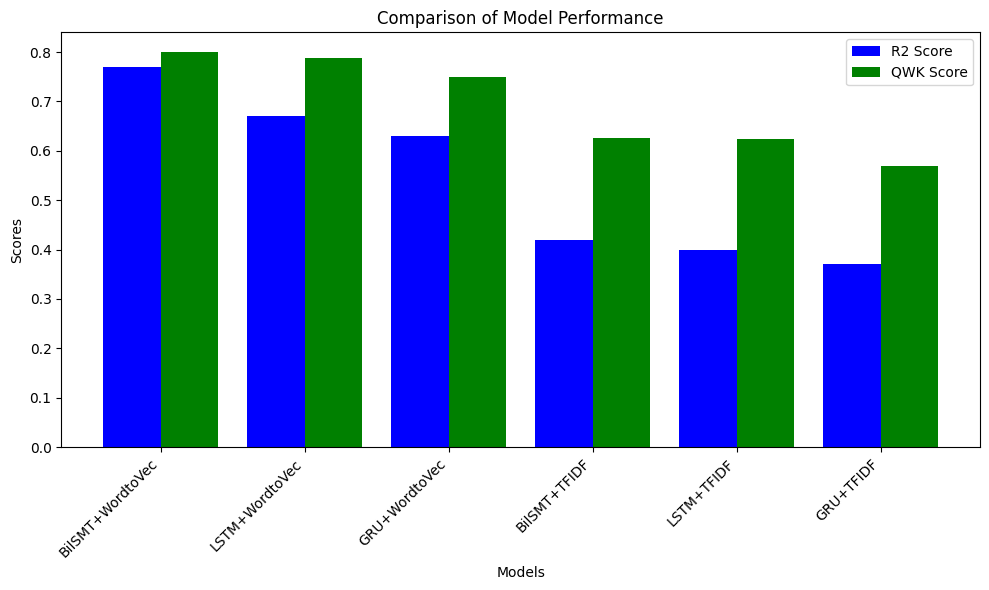

In [ ]:

def plot_comparison():
    models = [
        "BilSMT+WordtoVec", "LSTM+WordtoVec", "GRU+WordtoVec",
        "BilSMT+TFIDF", "LSTM+TFIDF", "GRU+TFIDF"
    ]
    qwk = [
        0.80, 0.788, 0.75, 0.625, 0.624, 0.57
    ]
    r2 = [
        0.77, 0.67, 0.63, 0.42, 0.4, 0.37
    ]
    df2 = pd.DataFrame({"Model": models, "QWK Score": qwk,"R2":r2})
    print(df2)


    x = np.arange(len(models))
    width = 0.4

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, r2, width, label='R2 Score', color='blue')
    bars2 = ax.bar(x + width/2, qwk, width, label='QWK Score', color='green')

    ax.set_xlabel('Models')
    ax.set_ylabel('Scores')
    ax.set_title('Comparison of Model Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Call plot function
plot_comparison()


# **Saving Best Model**



In [ ]:
#model metric into csv
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
model.save("essay_scoring_bilstm_wordtovec.h5")

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
loaded_model = load_model("essay_scoring_bilstm_wordtovec.h5")
print("Model loaded successfully!")


Model loaded successfully!


#**Evaluation of Results on Test Set**




In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
model = tf.keras.models.load_model('/content/essay_scoring_bilstm_wordtovec.h5', custom_objects={'MeanSquaredError': MeanSquaredError})
test_sequences = tokenizer.texts_to_sequences(test_data['essay'])
test_padded_sequences = pad_sequences(test_sequences, maxlen=300, padding='post')
test_predictions = model.predict(test_padded_sequences).flatten()
test_predictions_rounded = np.round(test_predictions)
qwk_score = cohen_kappa_score(test_data['score'], test_predictions_rounded, weights='quadratic')
print(f"Quadratic Weighted Kappa for the test set: {qwk_score}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Quadratic Weighted Kappa for the test set: 0.7936815708018666


**Test Set Result :**
QWK : 0.79

# **Testing Stored Model Real - Word Input Essay**



In [ ]:
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
model = load_model("/content/essay_scoring_bilstm_wordtovec.h5")
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)
MAX_SEQUENCE_LENGTH = 300
def preprocess_text(text):
    sequences = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    return padded_sequence
def predict_score(text):
    processed_text = preprocess_text(text)
    prediction = model.predict(processed_text)
    predicted_score = np.round(prediction).flatten()[0]
    return predicted_score




input_text='it was one of those days where i just sat around all day doing nothing but play  text and laugh at myself it was one of those days where no one bothered me no one even really talked to me no one told me to do chores by dinner time someone decided to call me up stairs to eat but let me tell you it was not anything like pizza although id rather eat it than get a lecture on not being thankful my brother came home for the first time in ever ate with us then decided to leave again but this time i asked to come with im so tired of beating  he said no of coarse i made my daddy change his mind for him of coarse i do not see why he would not let me come in the first place he was going to hang out with the guys i grew up with my friends not his anyways i got ready then we hit the road there him and i were laughing about dinner and what kind of music my mom listens to on our way to pick up my friends these guys are great all we do is crack jokes about each other and crack up but let us get down to business i did not tell you this but it is time around the of  fireworks are for sale and we are creating bombs out of them or they are since im a girl i guess im not allowed or something lame like that but there is this girl my brother likes and i guess he wants to impress excuse me impress her by showing up at her house so she can see these master pieces they have made that just makes me feel bad for him but honestly just made me laugh maybe she will be impressed key word maybe although no it will not because to this day they are still only friends so about these bombs complete duds we tried well i just watched over and over again to make em work but they would not do a thing eventually my friend put a whole bunch of s into my favorite stuffed animal it just made a bunch of sparkly colors and loud noises but it was pretty fun to watch we got in on video too it was a total good laugh for everyone after my brother said goodbye to his girl we decided to head home the thing is we had so many fireworks left we know this kid who lives somewhere on the way home so we decided to go by his house have get out of the truck light the firework on his porch have him jump in the tail of the trunk then drive off as fast as we could the first time we did it we could not stop laughing they did not come out of their house so we did it again they still did not come out we did it about one more time by then all the neighbors were out they were all so confused that just made us laugh even more it was so great we wanted to keep doing it but to someone else this time we know this girl who lives near all of us we thought why not it is not gonna hurt to stop there real quick and have some fun with her too apparently she thought different way different actually she thought it was the rudest thing ever we were just joking around gettin a laugh out of all our fun we were not being rude she is our friend long story short her mom got mad too and chased us down in her car she never caught us but she got our license plate number the next day on the of  she called the police they did not think it was a big deal but they still showed up at my house and talked to my parents about what went down i was at my boyfriends so lucky me i only had to talk to my mom on the phone about it she realized we were just having fun and actually laughed about it too that of was great it was one of those nights where you laughed the whole time and would not change a thing even if you got in trouble with the law for it something i will definitely never do again but im so glad i have this hilarious memory to reminisce on for the rest of my life'
predicted_score = predict_score(input_text)
print(f"Predicted Score: {predicted_score}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
Predicted Score: 6.0


## **Conclusion**


Based on the evaluation metrcs, **BilSMT+WordtoVec** performed the best, achieving the Highest QWK (0.8). This indicates that the combination of BilSMT+WordtoVec provides the most accurate and reliable predictions for automated grading.


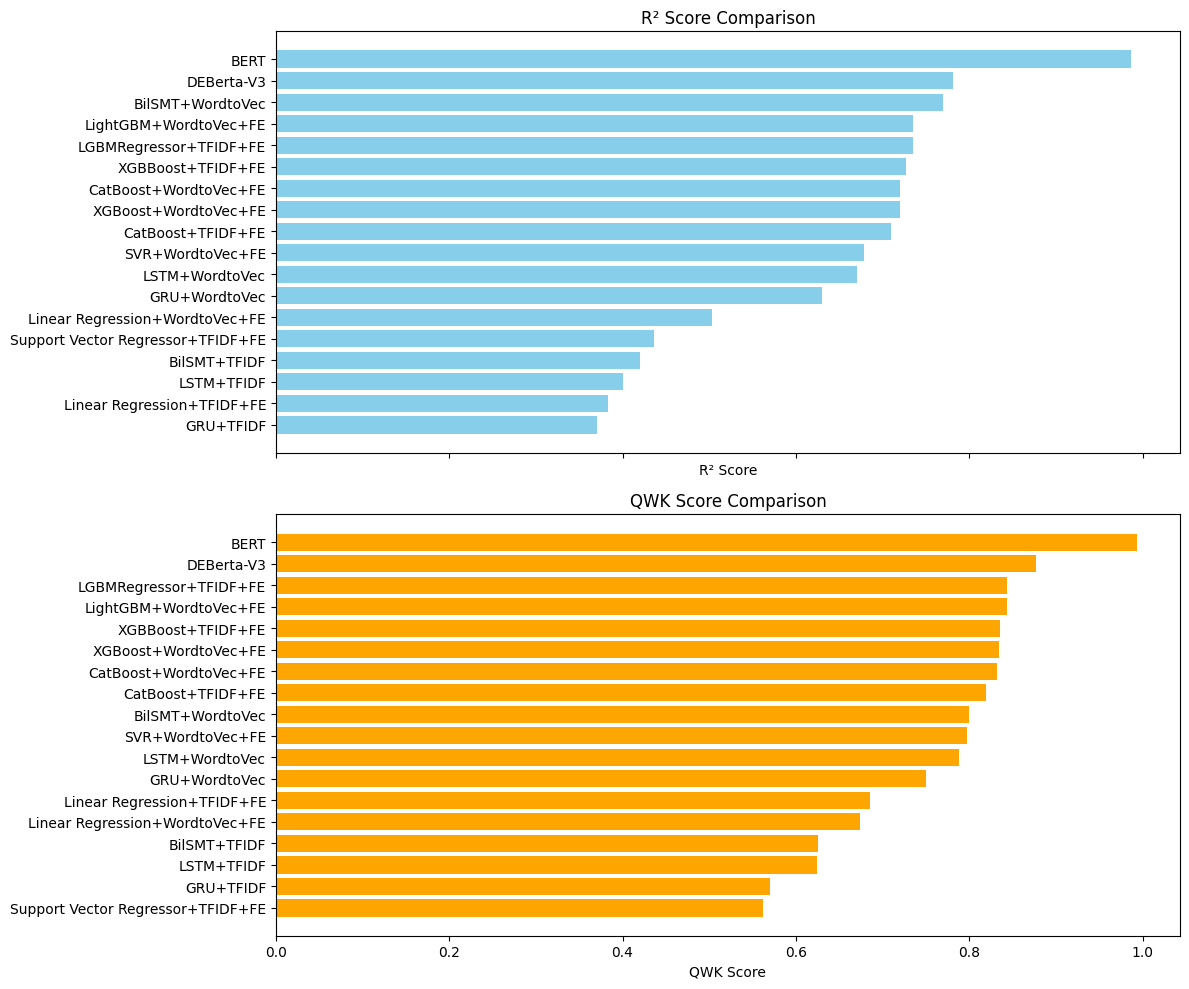

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating the data for the CSV file
data = [
    ["Linear Regression+WordtoVec+FE", 0.5036, 0.6734],
    ["XGBoost+WordtoVec+FE", 0.7200, 0.8346],
    ["CatBoost+WordtoVec+FE", 0.7204, 0.8325],
    ["SVR+WordtoVec+FE", 0.6783, 0.7977],
    ["LightGBM+WordtoVec+FE", 0.7355, 0.8433],
    ["Linear Regression+TFIDF+FE", 0.3833, 0.6860],
    ["XGBBoost+TFIDF+FE", 0.7270, 0.8351],
    ["CatBoost+TFIDF+FE", 0.7100, 0.8195],
    ["Support Vector Regressor+TFIDF+FE", 0.4367, 0.5620],
    ["LGBMRegressor+TFIDF+FE", 0.7355, 0.8433],
    ["BilSMT+WordtoVec", 0.77, 0.800],
    ["LSTM+WordtoVec", 0.67, 0.788],
    ["GRU+WordtoVec", 0.63, 0.750],
    ["BilSMT+TFIDF", 0.42, 0.625],
    ["LSTM+TFIDF", 0.40, 0.624],
    ["GRU+TFIDF", 0.37, 0.570],
    ["DEBerta-V3", 0.7812, 0.8767],
    ["BERT", 0.9868, 0.9935]
]

# Creating DataFrame
df = pd.DataFrame(data, columns=["Model", "R² Score", "QWK Score"])

# Sorting data by R² Score for better visualization
df_sorted = df.sort_values(by="R² Score", ascending=False)
df_sorted2=df.sort_values(by="QWK Score", ascending=True)

# Plotting QWK Score and R² Score separately
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# R² Score Plot
axes[0].barh(df_sorted["Model"], df_sorted["R² Score"], color="skyblue")
axes[0].set_title("R² Score Comparison")
axes[0].set_xlabel("R² Score")
axes[0].invert_yaxis()

# QWK Score Plot
axes[1].barh(df_sorted2["Model"], df_sorted2["QWK Score"], color="orange")
axes[1].set_title("QWK Score Comparison")
axes[1].set_xlabel("QWK Score")

plt.tight_layout()
plt.show()


In [ ]:
df

,Model,R² Score,QWK Score
0,Linear Regression+WordtoVec+FE,0.5036,0.6734
1,XGBoost+WordtoVec+FE,0.7200,0.8346
2,CatBoost+WordtoVec+FE,0.7204,0.8325
3,SVR+WordtoVec+FE,0.6783,0.7977
4,LightGBM+WordtoVec+FE,0.7355,0.8433
5,Linear Regression+TFIDF+FE,0.3833,0.6860
6,XGBBoost+TFIDF+FE,0.7270,0.8351
7,CatBoost+TFIDF+FE,0.7100,0.8195
8,Support Vector Regressor+TFIDF+FE,0.4367,0.5620
9,LGBMRegressor+TFIDF+FE,0.7355,0.8433
